In [2]:
# TBATS is a time-series forecasting model designed especially for data with complex or multiple seasonal patterns.

In [3]:
# Letter	Meaning
# T	Trigonometric representation of seasonality
# B	Box-Cox transformation
# A	ARMA errors
# T	Trend
# S	Seasonal components
# TBATS becomes especially interesting when you have multiple seasonalities.
#Standard TBATS is a univariate forecasting model.

In [4]:
import pandas as pd
import numpy as np

In [5]:
data=pd.read_csv('electricityConsumptionAndProductioction.csv')

In [6]:
data.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [7]:
data.shape

(62810, 10)

In [8]:
data['DateTime']=pd.to_datetime(data['DateTime'])

In [9]:
data=data.sort_values('DateTime')

In [10]:
data.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [11]:
data.dtypes

DateTime         datetime64[ns]
Consumption               int64
Production                int64
Nuclear                   int64
Wind                      int64
Hydroelectric             int64
Oil and Gas               int64
Coal                      int64
Solar                     int64
Biomass                   int64
dtype: object

In [12]:
data.set_index('DateTime',inplace=True)

In [13]:
data

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30
...,...,...,...,...,...,...,...,...,...
2026-03-14 19:00:00,7132,6937,1339,699,2560,1590,598,0,59
2026-03-14 20:00:00,7027,6827,1339,744,2538,1571,579,0,58
2026-03-14 21:00:00,6615,6612,1341,778,2291,1569,578,0,60


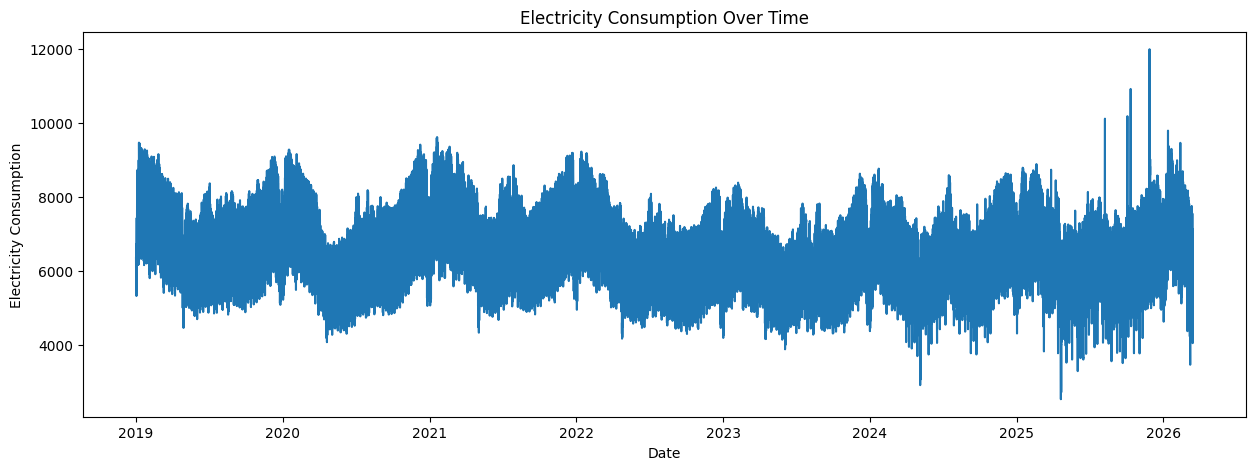

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(data.index, data["Consumption"])

plt.xlabel("Date")
plt.ylabel("Electricity Consumption")
plt.title("Electricity Consumption Over Time")

plt.show()

In [15]:
data.index.to_series().diff().value_counts().head(10)

DateTime
0 days 01:00:00    62720
0 days 03:00:00       43
0 days 00:00:00       11
0 days 04:00:00       10
0 days 06:00:00        7
0 days 02:00:00        6
0 days 05:00:00        3
0 days 07:00:00        3
0 days 08:00:00        1
0 days 11:00:00        1
Name: count, dtype: int64

In [16]:
time_diff = data.index.to_series().diff()

gaps = data[time_diff > pd.Timedelta(hours=1)]

print(gaps.index)

DatetimeIndex(['2019-03-31 04:00:00', '2020-03-29 04:00:00',
               '2021-03-28 04:00:00', '2022-03-27 04:00:00',
               '2023-03-26 04:00:00', '2024-04-06 05:00:00',
               '2024-05-08 03:00:00', '2024-05-10 00:00:00',
               '2024-05-13 01:00:00', '2024-05-16 23:00:00',
               '2024-05-17 20:00:00', '2024-05-18 00:00:00',
               '2024-05-30 13:00:00', '2024-06-10 13:00:00',
               '2024-06-29 21:00:00', '2024-07-08 19:00:00',
               '2024-07-08 23:00:00', '2024-07-09 03:00:00',
               '2024-07-11 20:00:00', '2024-07-14 21:00:00',
               '2024-07-22 22:00:00', '2024-07-26 00:00:00',
               '2024-08-19 22:00:00', '2024-08-25 01:00:00',
               '2024-08-30 20:00:00', '2024-09-08 22:00:00',
               '2024-09-12 22:00:00', '2024-09-21 22:00:00',
               '2024-09-22 22:00:00', '2024-09-23 22:00:00',
               '2024-10-19 21:00:00', '2024-10-24 21:00:00',
               '2024-11-

In [17]:
gap_info = pd.DataFrame({
    "DateTime": data.index,
    "TimeDifference": data.index.to_series().diff()
})

print(gap_info[gap_info["TimeDifference"] > pd.Timedelta(hours=1)])

                               DateTime  TimeDifference
DateTime                                               
2019-03-31 04:00:00 2019-03-31 04:00:00 0 days 02:00:00
2020-03-29 04:00:00 2020-03-29 04:00:00 0 days 02:00:00
2021-03-28 04:00:00 2021-03-28 04:00:00 0 days 02:00:00
2022-03-27 04:00:00 2022-03-27 04:00:00 0 days 02:00:00
2023-03-26 04:00:00 2023-03-26 04:00:00 0 days 02:00:00
...                                 ...             ...
2025-03-11 09:00:00 2025-03-11 09:00:00 0 days 03:00:00
2025-03-12 21:00:00 2025-03-12 21:00:00 0 days 03:00:00
2025-03-14 05:00:00 2025-03-14 05:00:00 0 days 03:00:00
2025-03-14 10:00:00 2025-03-14 10:00:00 0 days 04:00:00
2025-03-30 04:00:00 2025-03-30 04:00:00 0 days 02:00:00

[78 rows x 2 columns]


In [18]:
full_index = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="h"
)

print("Expected observations:", len(full_index))
print("Actual observations:", len(data))

Expected observations: 63120
Actual observations: 62810


In [19]:
missing_times = full_index.difference(data.index)

print("Missing timestamps:", len(missing_times))
print(missing_times[:20])

Missing timestamps: 321
DatetimeIndex(['2019-03-31 03:00:00', '2020-03-29 03:00:00',
               '2021-03-28 03:00:00', '2022-03-27 03:00:00',
               '2023-03-26 03:00:00', '2024-04-06 03:00:00',
               '2024-04-06 04:00:00', '2024-05-08 00:00:00',
               '2024-05-08 01:00:00', '2024-05-08 02:00:00',
               '2024-05-09 17:00:00', '2024-05-09 18:00:00',
               '2024-05-09 19:00:00', '2024-05-09 20:00:00',
               '2024-05-09 21:00:00', '2024-05-09 22:00:00',
               '2024-05-09 23:00:00', '2024-05-12 20:00:00',
               '2024-05-12 21:00:00', '2024-05-12 22:00:00'],
              dtype='datetime64[ns]', freq=None)


In [26]:
data = data.reindex(full_index)

ValueError: cannot reindex on an axis with duplicate labels

In [20]:
print(data.shape)
print(data.isnull().sum())

(62810, 9)
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


In [21]:
y=data['Consumption']

In [22]:
y.isna().sum()

np.int64(0)

In [23]:
data['Hour']=data.index.hour

In [24]:
daily_pattern=data.groupby('Hour')['Consumption'].mean()

In [25]:
daily_pattern

Hour
0     5825.199771
1     5615.414122
2     5497.845097
3     5445.916984
4     5476.508966
5     5590.784516
6     5913.925191
7     6441.031370
8     6813.103673
9     6927.783206
10    6866.388338
11    6770.694127
12    6717.934426
13    6732.376000
14    6662.681264
15    6663.904000
16    6775.234172
17    6985.482006
18    7150.132771
19    7275.783462
20    7315.567963
21    7143.011516
22    6655.816233
23    6172.178585
Name: Consumption, dtype: float64

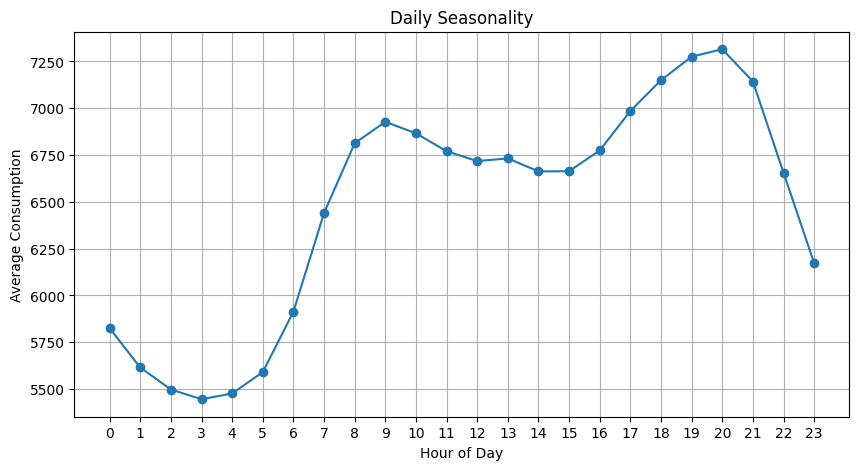

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(daily_pattern.index,daily_pattern.values,marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.title("Daily Seasonality")

plt.xticks(range(24))
plt.grid()

plt.show()

In [27]:
data["HourOfWeek"] = (
    data.index.dayofweek * 24
    + data.index.hour
)

weekly_pattern = data.groupby("HourOfWeek")["Consumption"].mean()

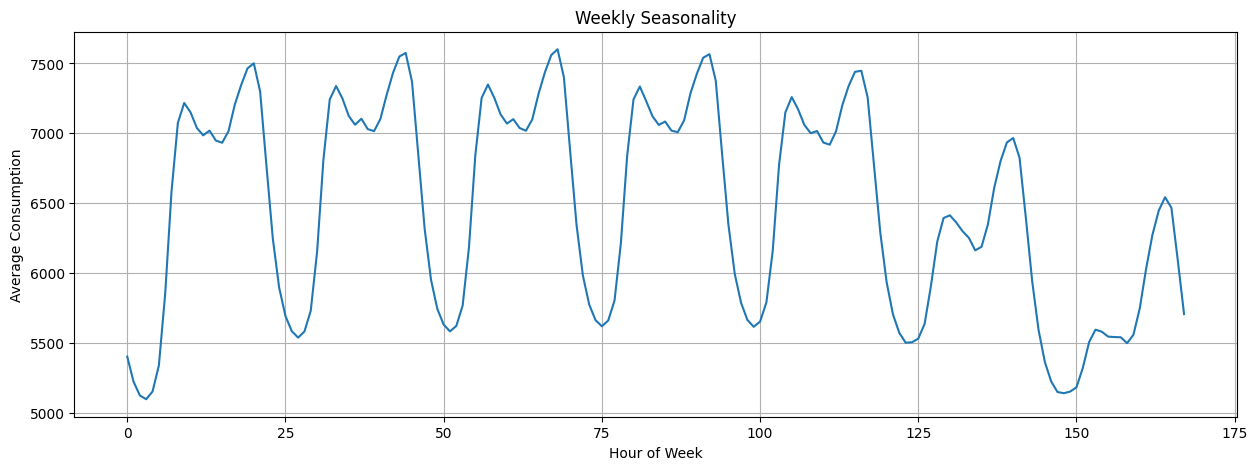

In [28]:
plt.figure(figsize=(15, 5))

plt.plot(weekly_pattern.index,weekly_pattern.values)

plt.xlabel("Hour of Week")
plt.ylabel("Average Consumption")
plt.title("Weekly Seasonality")

plt.grid()

plt.show()

In [29]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Hour,HourOfWeek
DateTime,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,24
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,25
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,26
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,27
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,28


In [30]:
test_size = 24 * 100

train = y.iloc[:-test_size]
test = y.iloc[-test_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 60410
Testing observations: 2400


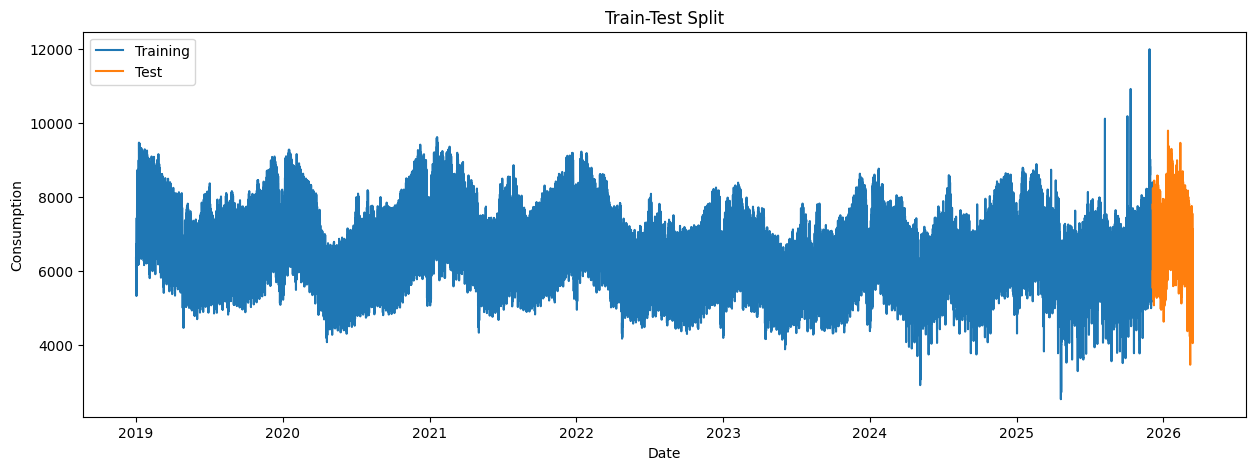

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Test")

plt.xlabel("Date")
plt.ylabel("Consumption")
plt.title("Train-Test Split")
plt.legend()

plt.show()

In [31]:
# pip install tbats

In [32]:
from tbats import TBATS

In [ ]:
estimator = TBATS(
    seasonal_periods=[24]
)

model = estimator.fit(train)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
forecast = model.forecast(steps=len(test))

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, forecast, label="TBATS Forecast")

plt.xlabel("Date")
plt.ylabel("Consumption")
plt.title("TBATS Forecast vs Actual")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mape = np.mean(
    np.abs((test - forecast) / test)
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

In [ ]:
estimator = TBATS(
    seasonal_periods=[24]
)

final_model = estimator.fit(y)

future_forecast = final_model.forecast(
    steps=24 * 100
)
print(future_forecast)

In [33]:
test_size = 24 * 365

train_small = y.iloc[-test_size:]
test=y.iloc[:-24*7]


In [ ]:
estimator = TBATS(
    seasonal_periods=[24]
)

model = estimator.fit(train_small)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
